Wymiary obrazu: 364x800, kanały: 3


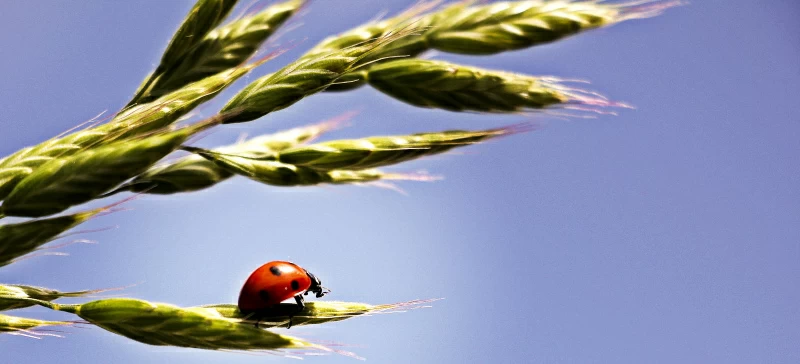

Rozmiar wektora osobliwych wartości: (364,)
k dla 90% wartości (przykład): 1


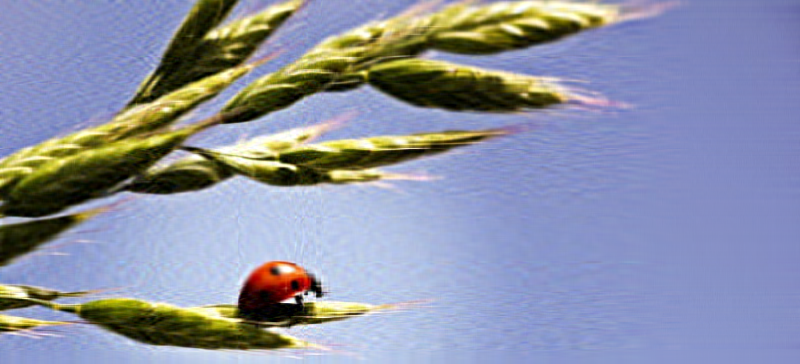

Minimalne k (ta sama liczba wartości singularnych dla każdego kanału) by zachować >=90% wartości: k=2, wartość=0.9137
Zapisano rekonstrukcję dla k=1 -> svd_results\recon_k1.png
Zapisano rekonstrukcję dla k=2 -> svd_results\recon_k2.png
Zapisano rekonstrukcję dla k=5 -> svd_results\recon_k5.png
Zapisano rekonstrukcję dla k=10 -> svd_results\recon_k10.png
Zapisano rekonstrukcję dla k=20 -> svd_results\recon_k20.png
Zapisano rekonstrukcję dla k=50 -> svd_results\recon_k50.png
Zapisano rekonstrukcję dla k=100 -> svd_results\recon_k100.png


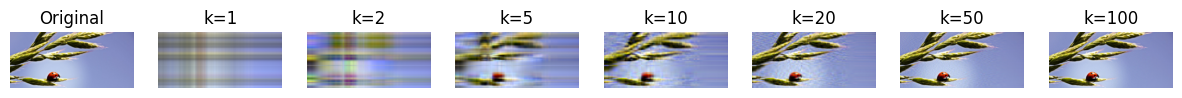

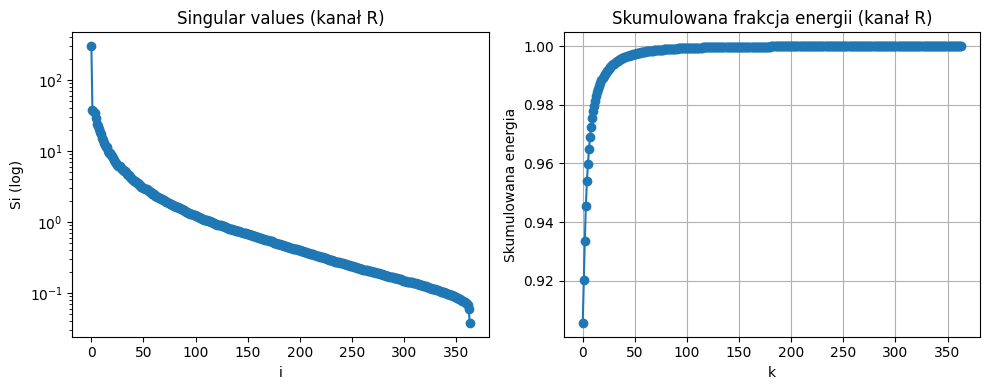

Pliki wynikowe: ['recon_k1.png', 'recon_k10.png', 'recon_k100.png', 'recon_k2.png', 'recon_k20.png', 'recon_k5.png', 'recon_k50.png']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from numpy.linalg import svd
from skimage import img_as_float, img_as_ubyte
from IPython.display import display
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from numpy.linalg import svd
from skimage import img_as_float, img_as_ubyte
from IPython.display import display
%matplotlib inline

img_path = "15.webp"   
if not os.path.exists(img_path):
    raise FileNotFoundError(f"Nie znaleziono pliku: {img_path} w katalogu roboczym.")
img_pil = Image.open(img_path).convert('RGB')
img = img_as_float(img_pil)  # float w zakresie [0,1]
h, w, c = img.shape
print(f"Wymiary obrazu: {h}x{w}, kanały: {c}")
display(img_pil)

# funkcja SVD i rekonstrukcja dla pojedynczego kanału
def svd_channel_reconstruct(channel, k):
    U, S, VT = svd(channel, full_matrices=False)
    Uk = U[:, :k]
    Sk = np.diag(S[:k])
    VTk = VT[:k, :]
    recon = Uk @ Sk @ VTk
    return recon, S

# test na jednym kanale
test_recon, test_S = svd_channel_reconstruct(img[..., 0], 10)
print("Rozmiar wektora osobliwych wartości:", test_S.shape)

# funkcja do znalezienia najmniejszego k zachowującego wartość (np. 0.90)
def k_for_energy(singular_values, energy_target=0.90):
    s2 = singular_values**2
    total = s2.sum()
    cumsum = np.cumsum(s2)
    k = int(np.searchsorted(cumsum, energy_target * total) + 1)
    return k, cumsum/total

# test
k_example, cum_rel = k_for_energy(test_S, 0.90)
print("k dla 90% wartości (przykład):", k_example)

# funkcja do kompresji i rekonstrukcji całego obrazu
def svd_image_reconstruct(img, k):
    h, w, c = img.shape
    recon_img = np.zeros_like(img)
    ks = []
    singulars = []
    for ch in range(c):
        recon_ch, S = svd_channel_reconstruct(img[..., ch], k)
        recon_img[..., ch] = recon_ch
        ks.append(k)
        singulars.append(S)
    recon_img = np.clip(recon_img, 0, 1)
    return recon_img, singulars

# test rekonstrukcji k=50
recon50, singulars = svd_image_reconstruct(img, 50)
display(Image.fromarray(img_as_ubyte(recon50)))

# wyznaczenie najmniejszego k które zachowuje 90% wartości globalnie
def find_k_global_for_energy(img, energy_target=0.90, max_k=None):
    h,w,c = img.shape
    ks = []
    cum_fractions = []
    max_k = max_k or min(h, w)
    S_list = []
    for ch in range(c):
        _, S = svd_channel_reconstruct(img[..., ch], min(50, max_k))
        S_list.append(S)
    s2_total = sum((S**2).sum() for S in S_list)
    for k in range(1, max_k+1):
        s2_k = 0.0
        for S in S_list:
            s2_k += (S[:k]**2).sum() if len(S) >= k else (S**2).sum()
        frac = s2_k / s2_total
        if frac >= energy_target:
            return k, frac
    return max_k, s2_k / s2_total

k90, frac90 = find_k_global_for_energy(img, 0.90, max_k=min(h,w))
print(f"Minimalne k by zachować >=90% wartości: k={k90}, wartość={frac90:.4f}")

# generowanie rekonstrukcji dla kilku k i zapisanie wyników
output_dir = "svd_results"
os.makedirs(output_dir, exist_ok=True)

k_values = [1, 5, 10, 20, 50, 100, k90]
k_values = sorted(set([k for k in k_values if k is not None and k>0 and k<=min(h,w)]))

results = {}
for k in k_values:
    recon, S_list = svd_image_reconstruct(img, k)
    fname = os.path.join(output_dir, f"recon_k{k}.png")
    Image.fromarray(img_as_ubyte(recon)).save(fname)
    results[k] = {"path": fname, "recon": recon, "singulars": S_list}
    print(f"Zapisano rekonstrukcję dla k={k} -> {fname}")

# pokazanie oryginału i kilku rekonstrukcji
def show_row(images, titles=None, figsize=(15,5)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i, im in enumerate(images):
        plt.subplot(1, n, i+1)
        plt.axis('off')
        plt.imshow(im)
        if titles:
            plt.title(titles[i])
    plt.show()

images = [img] + [results[k]["recon"] for k in k_values]
titles = ["Original"] + [f"k={k}" for k in k_values]
show_row(images, titles)

# wykres
S0 = singulars = results[k_values[-1]]["singulars"][0]
U0, S0_full, VT0 = svd(img[...,0], full_matrices=False)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.semilogy(S0_full, marker='o')
plt.title("Singular values (kanał R)")
plt.xlabel("i")
plt.ylabel("Si (log)")

plt.subplot(1,2,2)
cum = np.cumsum(S0_full**2) / np.sum(S0_full**2)
plt.plot(cum, marker='o')
plt.title("Skumulowana frakcja energii (kanał R)")
plt.xlabel("k")
plt.ylabel("Skumulowana energia")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Pliki wynikowe:", os.listdir(output_dir))
